# TS1: Generación y Análisis de Señales
Catalina Wynne

## Consigna del ejercicio 1 

Utilizando siempre N = 1000 muestras. Se pide:

Sintetizar:

Señal sinusoidal de 2 KHz que tenga al menos 10 puntos por período.

Misma señal con 2 W de potencia media y desfasada en π/2.

Una secuencia aleatoria de ruido normalmente distribuido con DC (valor medio) 0V y varianza 0.1 W.

Una secuencia aleatoria de ruido uniformemente distribuido con DC (valor medio) 0V y varianza 0.1 W. 

Un pulso rectangular de la misma frecuencia, 1 W de potencia y ciclo de actividad del 50% (Ver scipy.signal apartado Waveforms).

Para cada señal visualice el módulo de la transformada de Fourier.
Bonus:
🤯 Implementar alguna otra señal disponible en scipy.signal.
💎 Averiguar cómo se podría medir la potencia mediante la transformada de Fourier (Ver Teorema de Parseval)


## Introducción
En este trabajo se implementa un generador de señales discretas y se analiza el comportamiento temporal y espectral de diferentes tipos de señales.

En el primer ejercicio se generan señales sinusoidales, ruido aleatorio con distribución normal y uniforme, y una señal rectangular. Para cada caso se analiza la señal en el dominio temporal y se calcula el módulo de su Transformada Discreta de Fourier (DFT) mediante la Transformada Rápida de Fourier (FFT).

Además, se calcula la potencia media de las señales tanto en el dominio temporal como en el dominio frecuencial, verificando numéricamente el Teorema de Parseval.

Finalmente, como parte del bonus, se analiza una señal diente de sierra y se estudia su contenido espectral.

### Muestreo de una señal

Una señal continua puede representarse en forma discreta mediante un proceso de muestreo. Durante este proceso se toman muestras de la señal a intervalos regulares de tiempo.

La frecuencia de muestreo fs indica cuántas muestras de la señal se toman por segundo:

$$
f_s = \frac{1}{T_s}
$$

donde Ts es el período de muestreo.

### Muestras por período

Para una señal sinusoidal de frecuencia f, su período es:

$$
T = \frac{1}{f}
$$

La cantidad de muestras tomadas durante un período es:

$$
N_{per} = \frac{f_s}{f}
$$

La consigna requiere al menos 10 puntos por período para la señal de 2 kHz. En este trabajo se utilizará:

$$
f_s = 50\,kHz
$$

por lo que:

$$
N_{per} = \frac{50000}{2000}=25
$$

Se obtienen 25 muestras por período, cumpliendo la condición solicitada.

Para una señal sinusoidal de amplitud A y valor medio cero:

$$
x(t)=A\sin(2\pi ft+\phi)
$$

su potencia media es:

$$
P=\frac{A^2}{2}
$$

Por lo tanto, para obtener una potencia determinada puede calcularse la amplitud como:

$$
A=\sqrt{2P}
$$

### Transformada Discreta de Fourier

La Transformada Discreta de Fourier (DFT) permite representar una señal discreta en el dominio de la frecuencia. Para una señal de N muestras:

$$
X[k]=\sum_{n=0}^{N-1}x[n]e^{-j2\pi kn/N}
$$

El módulo de la DFT,

$$
|X[k]|
$$

permite observar cómo se distribuye el contenido de la señal en las distintas frecuencias.

### Transformada Rápida de Fourier

La FFT (Fast Fourier Transform) es un algoritmo eficiente para calcular la DFT. En Python puede calcularse mediante:

```python
np.fft.fft(x)


### Resolución frecuencial

La separación entre dos puntos consecutivos del espectro, denominada resolución frecuencial, está determinada por:

$$
\Delta f = \frac{f_s}{N}
$$

Para los parámetros utilizados:

$$
\Delta f = \frac{50000}{1000}=50\,Hz
$$

Por lo tanto, el espectro obtenido mediante la DFT tendrá una separación de 50 Hz entre bins de frecuencia.

### Frecuencia de Nyquist

La frecuencia de Nyquist corresponde a la mitad de la frecuencia de muestreo:

$$
f_N=\frac{f_s}{2}
$$

Esta frecuencia determina el límite superior de frecuencias que pueden representarse sin aliasing al realizar el muestreo.

En este trabajo:

$$
f_N=\frac{50000}{2}=25000\ Hz=25\ kHz
$$

Como la señal utilizada tiene una frecuencia de 2 kHz, se encuentra muy por debajo de la frecuencia de Nyquist.

### Definición de parámetros y funciones 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ======================
# PARÁMETROS
# ======================
fs = 50000 # frecuencia de muestreo
N = 1000      # cantidad de muestras
f = 2000      # frecuencia señal principal
Ts = 1/fs

tt = np.arange(N) * Ts

#Vector de frecuencia en kHz
ff = np.fft.fftfreq(N, d=Ts)/1000
# Semilla para reproducibilidad de las señales aleatorias
np.random.seed(42)

# ======================
# Señal senoidal 
# ======================
def mi_funcion_sen(vmax, dc, f, fase, N, fs):
    tt = np.arange(N) / fs
    xx = dc + vmax * np.sin(2 * np.pi * f * tt + fase)
    return tt, xx

## Ejercicio 1: Síntesis y Análisis Espectral de Señales

Sintetizamos las 5 señales requeridas utilizando los parámetros base:

1. **Señal Senoidal de 2 kHz:** Amplitud $1\text{ V}$.
2. **Señal Senoidal de 2 W y fase $\pi/2$:** Como $P = \frac{V_{max}^2}{2}$, para $P = 2\text{ W}$ resulta $V_{max} = \sqrt{2 \cdot P} = 2\text{ V}$.
3. **Ruido Gaussiano (Normal):** $DC = 0\text{ V}$ y varianza $\sigma^2 = 0.1\text{ W}$ ($\text{desviación estándar} = \sqrt{0.1}$).
4. **Ruido Uniforme:** $DC = 0\text{ V}$ y varianza $\sigma^2 = 0.1\text{ W}$ (límites $[-a, a]$ con $a = \sqrt{0.3}$).
5. **Pulso Rectangular (2 kHz, 1 W, Ciclo de actividad 50%):** Generado con `scipy.signal.square`.

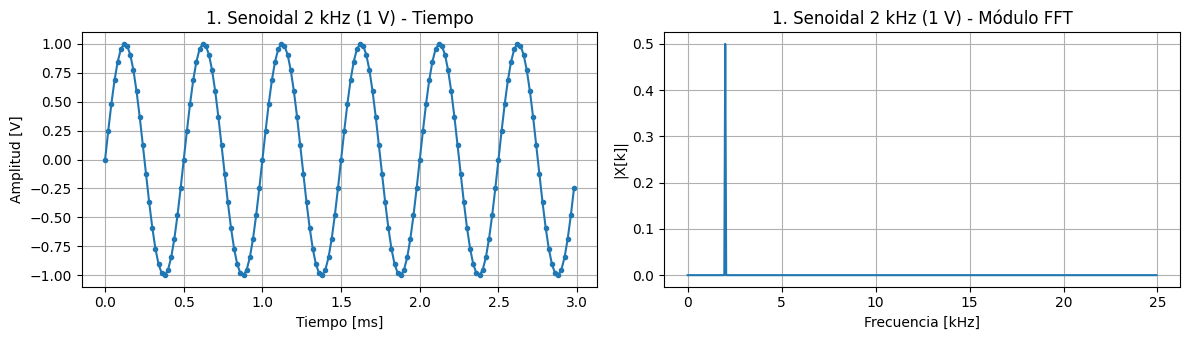

In [2]:
# 1) Senoidal 2 kHz (1 V)
tt, x1 = mi_funcion_sen(vmax=1, dc=0, f=f, fase=0, N=N, fs=fs)

# FFT normalizada
X1 = np.fft.fft(x1)
X1_modulo = np.abs(X1) / N

# Gráfico
plt.figure(figsize=(12, 3.5))
plt.subplot(1, 2, 1)
plt.plot(tt[:150] * 1000, x1[:150],marker='o', markersize=3)
plt.title("1. Senoidal 2 kHz (1 V) - Tiempo")
plt.xlabel("Tiempo [ms]")
plt.ylabel("Amplitud [V]")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(ff[:N//2], X1_modulo[:N//2])
plt.title("1. Senoidal 2 kHz (1 V) - Módulo FFT")
plt.xlabel("Frecuencia [kHz]")
plt.ylabel("|X[k]|")
plt.grid(True)

plt.tight_layout()
plt.show()


### Analisis del inciso 1
En el dominio temporal se observa una señal sinusoidal de 2 kHz y amplitud 1 V, cuyo período es:

$$
T=\frac{1}{2000}=0.5\ ms
$$

Con una frecuencia de muestreo de 50 kHz se obtienen:

$$
N_{per}=\frac{50000}{2000}=25
$$

muestras por período, cumpliendo la condición de tener al menos 10 puntos por período.

En la FFT se observa un pico en 2 kHz, correspondiente a la frecuencia de la señal, con un módulo aproximado de 0.5. Además, como $f_N=25$ kHz, se cumple el criterio de Nyquist y no se produce aliasing.


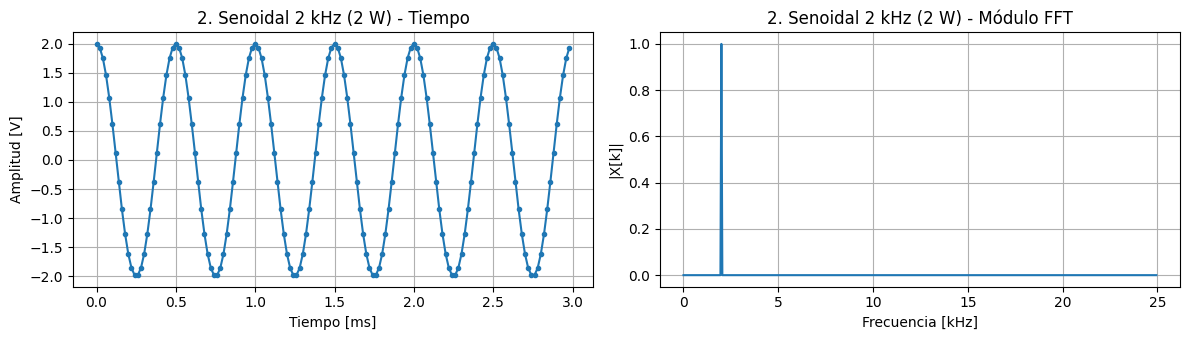

In [3]:

# 2) Senoidal 2 W y Fase π/2 (A = sqrt(2*P) = 2 V)
tt, x2 = mi_funcion_sen(vmax=2, dc=0, f=f, fase=np.pi/2, N=N, fs=fs)

# FFT normalizada
X2 = np.fft.fft(x2)
X2_modulo = np.abs(X2) / N

# Gráfico
plt.figure(figsize=(12, 3.5))

plt.subplot(1, 2, 1)
plt.plot(tt[:150] * 1000, x2[:150],marker='o', markersize=3)
plt.title("2. Senoidal 2 kHz (2 W) - Tiempo")
plt.xlabel("Tiempo [ms]")
plt.ylabel("Amplitud [V]")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(ff[:N//2], X2_modulo[:N//2])
plt.title("2. Senoidal 2 kHz (2 W) - Módulo FFT")
plt.xlabel("Frecuencia [kHz]")
plt.ylabel("|X[k]|")
plt.grid(True)

plt.tight_layout()
plt.show()


### Análisis del inciso 2
En el dominio temporal se observa una señal sinusoidal de 2 kHz, con amplitud máxima de 2 V y un desfase de $\pi/2$, por lo que comienza en su valor máximo positivo.

La potencia media de una senoide es:

$$
P=\frac{A^2}{2}=\frac{2^2}{2}=2\ W
$$

cumpliendo con la condición solicitada.

En la FFT se observa un pico en 2 kHz, al igual que en el caso anterior, pero con un módulo aproximadamente igual a 1 debido al aumento de amplitud.


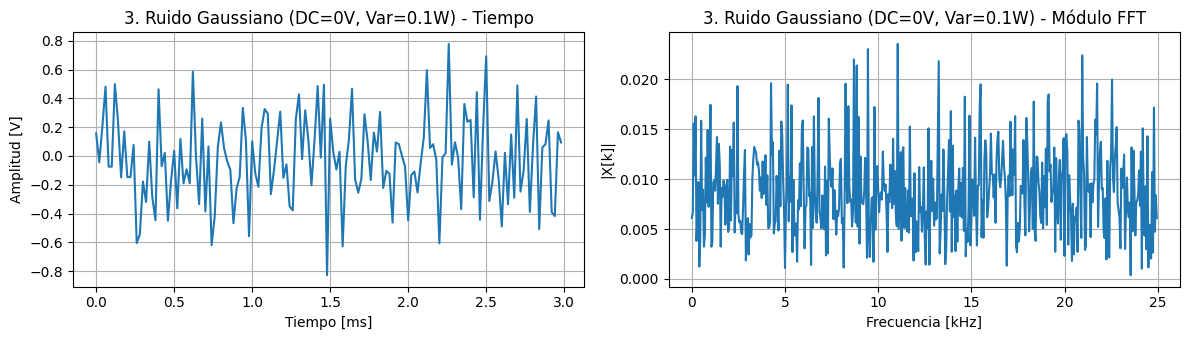

In [4]:
# 3) Ruido Gaussiano (DC=0V, Var=0.1W)

x3 = np.random.normal(loc=0.0, scale=np.sqrt(0.1), size=N)

# FFT normalizada
X3 = np.fft.fft(x3)
X3_modulo = np.abs(X3) / N

# Gráfico
plt.figure(figsize=(12, 3.5))

plt.subplot(1, 2, 1)
plt.plot(tt[:150] * 1000, x3[:150])
plt.title("3. Ruido Gaussiano (DC=0V, Var=0.1W) - Tiempo")
plt.xlabel("Tiempo [ms]")
plt.ylabel("Amplitud [V]")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(ff[:N//2], X3_modulo[:N//2])
plt.title("3. Ruido Gaussiano (DC=0V, Var=0.1W) - Módulo FFT")
plt.xlabel("Frecuencia [kHz]")
plt.ylabel("|X[k]|")
plt.grid(True)

plt.tight_layout()
plt.show()

### Análisis del inciso 3 

En el dominio temporal se observa una señal aleatoria con valor medio igual a 0 V, sin un comportamiento periódico definido. En la FFT se observa que la energía está distribuida en un amplio rango de frecuencias, sin un pico dominante, esto se debe a que es ruido Gaussiano.

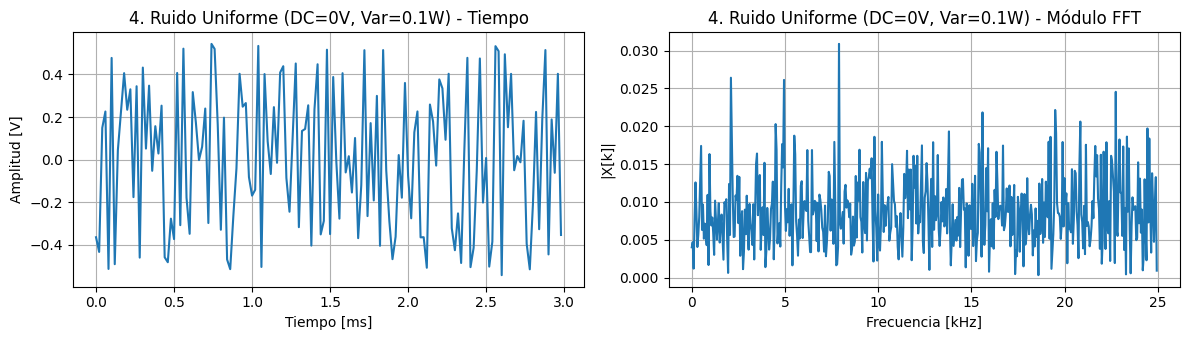

In [5]:
# 4) Ruido Uniforme (DC=0V, Var=0.1W)

a = np.sqrt(0.3)
x4 = np.random.uniform(low=-a, high=a, size=N)

# FFT normalizada
X4 = np.fft.fft(x4)
X4_modulo = np.abs(X4) / N

# Gráfico
plt.figure(figsize=(12, 3.5))

plt.subplot(1, 2, 1)
plt.plot(tt[:150] * 1000, x4[:150])
plt.title("4. Ruido Uniforme (DC=0V, Var=0.1W) - Tiempo")
plt.xlabel("Tiempo [ms]")
plt.ylabel("Amplitud [V]")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(ff[:N//2], X4_modulo[:N//2])
plt.title("4. Ruido Uniforme (DC=0V, Var=0.1W) - Módulo FFT")
plt.xlabel("Frecuencia [kHz]")
plt.ylabel("|X[k]|")
plt.grid(True)

plt.tight_layout()
plt.show()

### Analisis del inciso 4 

En el dominio temporal se observa una señal aleatoria con valor medio aproximadamente igual a 0 V y valores acotados entre $-\sqrt{0.3}$ y $\sqrt{0.3}$.

En la FFT se observa energía distribuida en un amplio rango de frecuencias, sin un pico dominante, al igual que en el ruido Gaussiano. Esto se debe a que ambos son señales aleatorias sin una frecuencia definida.

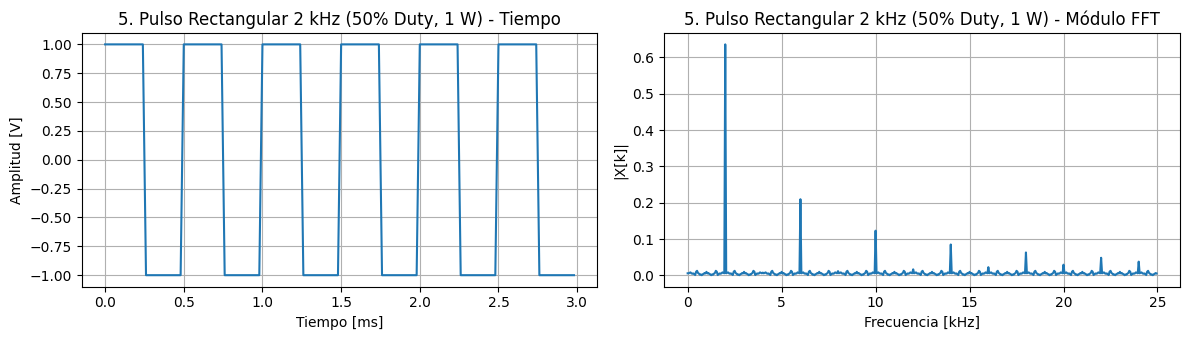

In [6]:
# 5) Pulso Rectangular 2 kHz (50% Duty, 1 W)

x5 = signal.square(2 * np.pi * f * tt, duty=0.5)

# FFT normalizada
X5 = np.fft.fft(x5)
X5_modulo = np.abs(X5) / N

# Gráfico
plt.figure(figsize=(12, 3.5))

plt.subplot(1, 2, 1)
plt.plot(tt[:150] * 1000, x5[:150])
plt.title("5. Pulso Rectangular 2 kHz (50% Duty, 1 W) - Tiempo")
plt.xlabel("Tiempo [ms]")
plt.ylabel("Amplitud [V]")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(ff[:N//2], X5_modulo[:N//2])
plt.title("5. Pulso Rectangular 2 kHz (50% Duty, 1 W) - Módulo FFT")
plt.xlabel("Frecuencia [kHz]")
plt.ylabel("|X[k]|")
plt.grid(True)

plt.tight_layout()
plt.show()


### Análisis del inciso 5
En el dominio temporal se observa una señal rectangular de 2 kHz con un ciclo de actividad del 50%, alternando entre valores positivos y negativos.

En la FFT se observa un pico en 2 kHz y componentes en sus armónicos impares (6 kHz, 10 kHz, etc.), característica del espectro de una señal rectangular.

## BONUS
Se utilizo la señal diente de sierra para simular la señal adicional pedida.


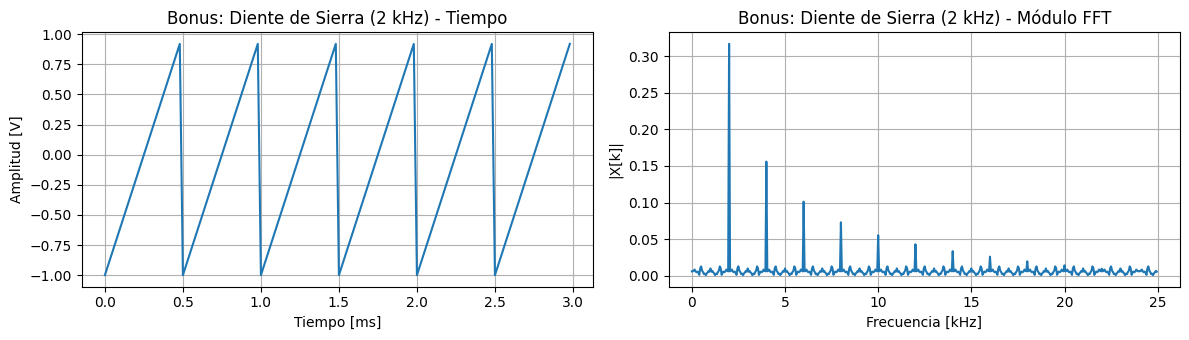

In [7]:
# BONUS) Diente de Sierra 2 kHz
x_saw = signal.sawtooth(2 * np.pi * f * tt)

# FFT normalizada
Xsaw = np.fft.fft(x_saw)
Xsaw_modulo = np.abs(Xsaw) / N

# Gráfico
plt.figure(figsize=(12, 3.5))

plt.subplot(1, 2, 1)
plt.plot(tt[:150] * 1000, x_saw[:150])
plt.title("Bonus: Diente de Sierra (2 kHz) - Tiempo")
plt.xlabel("Tiempo [ms]")
plt.ylabel("Amplitud [V]")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(ff[:N//2], Xsaw_modulo[:N//2])
plt.title("Bonus: Diente de Sierra (2 kHz) - Módulo FFT")
plt.xlabel("Frecuencia [kHz]")
plt.ylabel("|X[k]|")
plt.grid(True)

plt.tight_layout()
plt.show()

### Análisis del Bonus 
En el dominio temporal se observa una señal diente de sierra de 2 kHz, caracterizada por un crecimiento lineal seguido de una caída abrupta.

En la FFT se observa un pico en la frecuencia fundamental de 2 kHz y componentes en sus armónicos, que aparecen con amplitudes decrecientes.

### Teorema de Parseval

El Teorema de Parseval permite calcular la potencia media de una señal tanto en el dominio temporal como en el dominio frecuencial.

Utilizando la DFT normalizada:

$$
X[k]=\frac{1}{N}DFT\{x[n]\}
$$

la potencia media puede obtenerse mediante:

$$
P=\sum_{k=0}^{N-1}|X[k]|^2
$$

Por lo tanto, se verifica que:

$$
P_{tiempo}=P_{frecuencia}
$$

Se utiliza esta propiedad para comprobar la potencia de las señales generadas.

In [8]:
# Potencia en el tiempo
P1_t = np.mean(x1**2)
P2_t = np.mean(x2**2)
P3_t = np.mean(x3**2)
P4_t = np.mean(x4**2)
P5_t = np.mean(x5**2)
Psaw_t = np.mean(x_saw**2)

# Potencia en frecuencia utilizando el Teorema de Parseval
P1_f = np.sum(np.abs(np.fft.fft(x1) / N)**2)
P2_f = np.sum(np.abs(np.fft.fft(x2) / N)**2)
P3_f = np.sum(np.abs(np.fft.fft(x3) / N)**2)
P4_f = np.sum(np.abs(np.fft.fft(x4) / N)**2)
P5_f = np.sum(np.abs(np.fft.fft(x5) / N)**2)
Psaw_f = np.sum(np.abs(np.fft.fft(x_saw) / N)**2)

# Mostrar resultados
print("=" * 75)
print("VERIFICACIÓN DEL TEOREMA DE PARSEVAL")
print("=" * 75)
print(f"{'Señal':<42} | {'P tiempo [W]':<14} | {'P frecuencia [W]':<18}")
print("-" * 75)

print(f"{'1. Senoidal 2 kHz (1 V)':<42} | {P1_t:<14.5f} | {P1_f:<18.5f}")
print(f"{'2. Senoidal 2 kHz (2 W, fase π/2)':<42} | {P2_t:<14.5f} | {P2_f:<18.5f}")
print(f"{'3. Ruido Gaussiano (Var=0.1 W)':<42} | {P3_t:<14.5f} | {P3_f:<18.5f}")
print(f"{'4. Ruido Uniforme (Var=0.1 W)':<42} | {P4_t:<14.5f} | {P4_f:<18.5f}")
print(f"{'5. Pulso Rectangular (Duty 50%)':<42} | {P5_t:<14.5f} | {P5_f:<18.5f}")
print(f"{'Bonus: Diente de Sierra':<42} | {Psaw_t:<14.5f} | {Psaw_f:<18.5f}")

print("=" * 75)

VERIFICACIÓN DEL TEOREMA DE PARSEVAL
Señal                                      | P tiempo [W]   | P frecuencia [W]  
---------------------------------------------------------------------------
1. Senoidal 2 kHz (1 V)                    | 0.50000        | 0.50000           
2. Senoidal 2 kHz (2 W, fase π/2)          | 2.00000        | 2.00000           
3. Ruido Gaussiano (Var=0.1 W)             | 0.09583        | 0.09583           
4. Ruido Uniforme (Var=0.1 W)              | 0.09970        | 0.09970           
5. Pulso Rectangular (Duty 50%)            | 1.00000        | 1.00000           
Bonus: Diente de Sierra                    | 0.33440        | 0.33440           


### Conclusiones
En este ejercicio se sintetizaron y analizaron distintos tipos de señales discretas, corroborando como el contenido espectral refleja la naturaleza temporal:

Con respecto a las señales sinusoidales, presentan un pico en la frecuencia de la señal al graficar de 0 a Nyquist, con una amplitud proporcional a la señal en el tiempo (A/2), confirmando que una señal periódica y determinística concentra su energía en una frecuencia puntual.

Para los ejercicios de ruido, al no ser periódicaos, la energía se distribuye en todo el rango de frecuencias sin picos dominantes. Se distinguen de las señales sinusoidales aunque tengan potencia media similar.

En cuanto al pulso rectangular y el bonus de la señal diente de sierra, son periódicas no sinusoidales, es decir, concentran su energía en la frecuencia fundamental y en sus armónicos asociados.

Para todos los tipos de señales se verificó numéricamente el Teorema de Parseval, la potencia media en el dominio temporal coincidió con la que se calculó mediante el módulo de la DFT normalizada, afirmando que la FFT se puede utilizar para medir la potencia.



## Consigna del ejercicio 2 
Hacer en lápiz y papel y subir un PDF con la resolución.

Dado h[n] = δ[n] - δ[n - 4], encontrar y[n] = x[n] * h[n] para cada una de las siguientes x[n]:

a) x[n] = cos(ω₀.n. TS). Expresar la respuesta como un único coseno de la forma A cos(ω₀. n . TS + φ).

b) x[n] = (1/2)ⁿ u[n].

c) x[n] = u[n + 1] - u[n - 2].

Bonus:

🤯 Calcular la DFT de y(n) para N=8.

💎 Simular en Python. Ver la función convolve y FFT.

Hacer en lápiz y papel y subir un PDF con la resolución.


In [9]:
from IPython.display import IFrame

url_pdf = "https://raw.githubusercontent.com/CATALINAWYNNE/Repositorio-APS/main/TS1.pdf"
visor_google = f"https://docs.google.com/gview?url={url_pdf}&embedded=true"

IFrame(visor_google, width=1000, height=800)

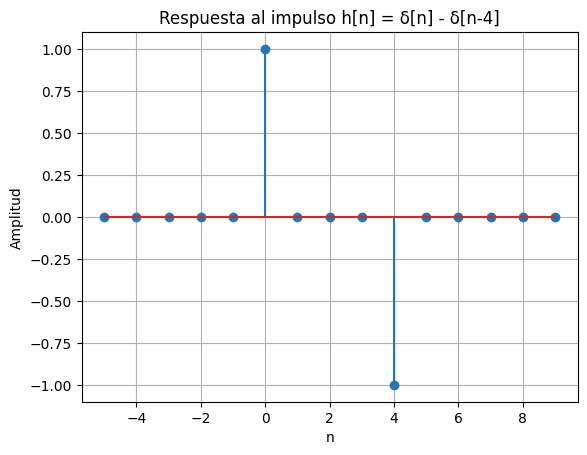

In [10]:
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(-5, 10)

def delta(n):
    return (n == 0).astype(float)

# sistema
h = delta(n) - delta(n-4)

plt.stem(n, h)
plt.title("Respuesta al impulso h[n] = δ[n] - δ[n-4]")
plt.xlabel ("n")
plt.ylabel ("Amplitud")
plt.grid()
plt.show()

Al restar dos cosenos de igual frecuencia pero desplazados en el tiempo, se obtiene otra señal cosenoidal con distinta amplitud y fase. 

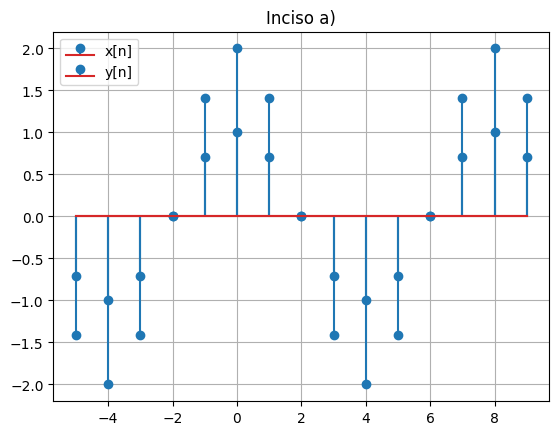

In [11]:
fs = 8000
f0 = 1000
Ts = 1/fs

x = np.cos(2*np.pi*f0*n*Ts)
x_shift = np.cos(2*np.pi*f0*(n-4)*Ts)

y = x - x_shift

plt.stem(n, x)
plt.stem(n, y)
plt.title("Inciso a)")
plt.legend(["x[n]", "y[n]"])
plt.grid()
plt.show()

Se observa que y[n] es otra señal cosenoidal de la misma frecuencia que x[n], con amplitud y fase modificadas. 
Esto se debe a que el  corrimiento de 4 muestras es equivalente a medio período de la señal entonces x[n-4]=-x[n] y el sistema lo que hace es duplicar la amplitud y[n]=2x[n], quedando con fase nula.

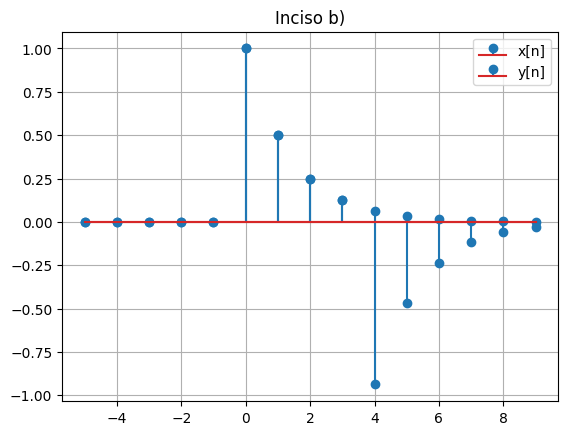

In [12]:
x = (0.5**n) * (n >= 0)
x_shift = (0.5**(n-4)) * (n >= 4)

y = x - x_shift
plt.stem(n, x)
plt.stem(n, y)
plt.title("Inciso b)")
plt.legend(["x[n]", "y[n]"])
plt.grid()
plt.show()

Se observa una señal decreciente que, a partir de cierto punto, presenta valores negativos debido a la resta de la señal desplazada.

Esto refleja el efecto del sistema sobre señales no periódicas.

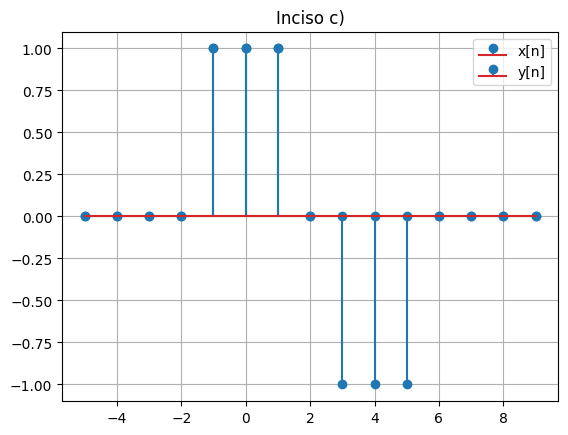

In [13]:
x = (n >= -1).astype(float) - (n >= 2).astype(float)
x_shift = (n >= 3).astype(float) - (n >= 6).astype(float)

y = x - x_shift

plt.stem(n, x)
plt.stem(n, y)
plt.title("Inciso c)")
plt.legend(["x[n]", "y[n]"])
plt.grid()
plt.show()

Se observa que la señal de salida presenta dos regiones: 

Un pulso positivo corresspondiente a la señal original.

Un pulso negativo desplazado 4 muestras. 

Esto es consistente con la operación de resta entre ambas señales.

### Conclusión 
El sistema definido por h [n] = δ[n] - δ[n-4] actúa como un operador de diferencia.

Se observó que:

En señales periódicas, modifica amplitud y fase.

En señales exponenciales, introduce cambios de signo.

En señales por tramos, genera copias desplazadas con signos opuestos.

Esto permite interpretar al sistema como un filtro que resalta cambios en la señal.